In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("../../Data/1-studyhours.csv")

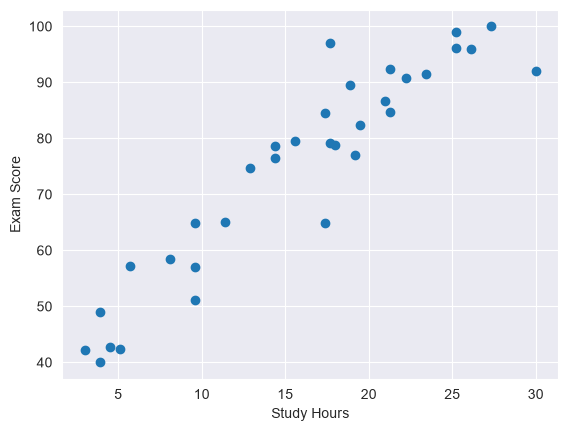

In [4]:
plt.scatter(df["Study Hours"], df["Exam Score"])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.show()

In [9]:
# Double brackets '[[]]' return a DataFrame (2D), which is required for X.
X = df[["Study Hours"]]

# Single brackets '[]' return a Series (1D), which is sufficient for target y.
y = df["Exam Score"]

## 1- Train Test Split

In [6]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 15)

In [11]:
X_train

,Study Hours
18,17.4
1,9.6
2,4.5
32,18.9
6,19.2
3,11.4
29,19.5
26,9.6
9,17.4
4,14.4


In [12]:
X_test

,Study Hours
25,5.1
14,21.0
30,23.4
16,5.7
24,9.6
20,3.9
19,21.3


## 2- Standardize the data

**🇹🇷 Türkçe:**
Bu adımda, veri setindeki sayısal özelliklerin (features) aynı ölçeğe getirilmesi için **Standartlaştırma (Standardization)** işlemi uygulanmaktadır.

* **Amaç:** Farklı ölçeklere sahip değişkenlerin (örneğin yaş ile yıllık gelir) makine öğrenmesi modelleri üzerinde orantısız bir ağırlık oluşturmasını engellemek ve algoritmaların daha hızlı çalışmasını sağlamak.
* **Yöntem:** Z-skoru formülü kullanılarak, ilgili sütunun **ortalaması 0** ve **standart sapması 1** olacak şekilde değerler dönüştürülür.

**🇬🇧 English:**
In this step, **Standardization** is applied to scale the numerical features in the dataset to a common scale.

* **Objective:** To prevent features with vastly different ranges (e.g., age vs. annual income) from disproportionately dominating machine learning models and to help algorithms converge faster.
* **Method:** Using the Z-score formula, the values are transformed so that the feature has a **mean of 0** and a **standard deviation of 1**.

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()

In [15]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
X_train

array([[ 0.11794385],
       [-0.97424848],
       [-1.68837424],
       [ 0.32798083],
       [ 0.36998823],
       [-0.7222041 ],
       [ 0.41199563],
       [-0.97424848],
       [ 0.11794385],
       [-0.30213013],
       [ 0.15995124],
       [ 0.66404001],
       [-0.13410054],
       [ 1.50418796],
       [-0.51216711],
       [ 0.15995124],
       [-0.30213013],
       [ 1.21013618],
       [ 1.33615837],
       [ 0.7900622 ],
       [-1.77238903],
       [-1.89841122],
       [ 0.20195864],
       [ 1.88225453],
       [-1.18428547],
       [ 1.21013618]])

### **3) Model Oluşturma / Model Building**

Veri ön işleme ve özellik mühendisliği adımlarını tamamladıktan sonra sıradaki aşama **modeli oluşturmak**tır. Bu projede, sayısal bir hedef değişkeni tahmin etmek için `scikit-learn` kütüphanesinin sunduğu **Doğrusal Regresyon (Linear Regression)** algoritmasını kullanacağız.

*After completing the data preprocessing and feature engineering steps, the next stage is **building the model**. In this project, we will use the **Linear Regression** algorithm from `scikit-learn` to predict a numerical target variable.*

Linear Regression, bağımsız değişkenler (features) ile bağımlı değişken (target) arasında doğrusal bir ilişki olduğunu varsayar ve şu denklemi öğrenmeye çalışır:

*Linear Regression assumes a linear relationship between the independent variables (features) and the dependent variable (target), and tries to learn the following equation:*

$$
y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \dots + \beta_nx_n + \epsilon
$$

- $y$: tahmin edilmek istenen hedef değişken / *the target variable to be predicted*
- $\beta_0$: sabit terim (intercept) / *the intercept term*
- $\beta_1, \beta_2, \dots, \beta_n$: her bir özelliğin katsayısı / *coefficient of each feature*
- $\epsilon$: hata terimi / *the error term*

📌 **Bu adımda yapılacaklar / Steps in this section:**
1. `LinearRegression` sınıfından bir model nesnesi oluşturmak — *Create a model instance from the `LinearRegression` class*
2. Modeli eğitim verisiyle eğitmek (`.fit()`) — *Train the model on the training data (`X_train`, `y_train`)*
3. Test verisi üzerinde tahmin yapmak (`.predict()`) — *Make predictions on the test data*

In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
regression = LinearRegression()

In [19]:
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[16.18]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,76.91
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[5.1]


In [20]:
print("Coefficients: ", regression.coef_)
print("Intercept: ", regression.intercept_)

Coefficients:  [16.17860223]
Intercept:  76.9076923076923


 **y = 76.90 + 16.17x**

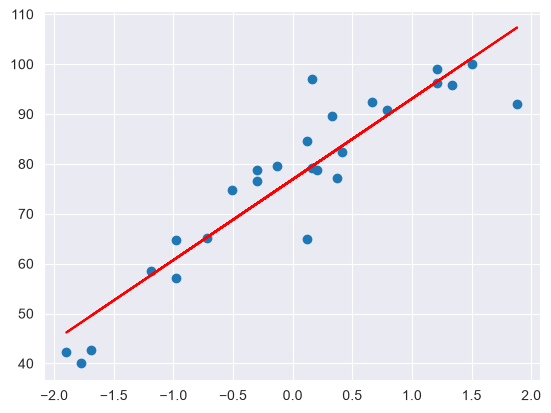

In [22]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train), "r")
plt.show()

In [23]:
regression.predict([[20]])

array([400.47973694])

⚠️ **Bu şekilde kullanamayız / We cannot use it this way**

`X` değerini eğitim öncesinde **scale (ölçeklendirme)** işleminden geçirmiştik. Bu yüzden modele tahmin (`predict`) yaptırırken de ham (scale edilmemiş) bir değer değil, **aynı scaler ile dönüştürülmüş (scale edilmiş) halini** girmemiz gerekiyor. Aksi takdirde model, eğitim sırasında öğrendiği ölçekten tamamen farklı bir değerle karşılaşır ve tahmin sonucu (`400.47973694`) anlamsız/yanıltıcı olur.

*Before training, we had **scaled** the `X` values. Therefore, when making a prediction with `.predict()`, we must not pass a raw (unscaled) value — we need to pass the value after transforming it with the **same scaler**. Otherwise, the model receives a value on a completely different scale than what it learned during training, making the prediction result (`400.47973694`) meaningless/misleading.*

✅ **Doğru kullanım / Correct usage:**

In [24]:
regression.predict(scaler.transform([[20]]))

C:\Users\efeka\PycharmProjects\PythonProject1\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([84.70590731])

### **4) Model Doğruluğu Kontrolü / Model Accuracy Evaluation**

Modelimizi eğittikten ve tahminler ürettikten sonra, bu tahminlerin **gerçek değerlere ne kadar yakın olduğunu** ölçmemiz gerekir. Bunun için regresyon problemlerinde yaygın olarak kullanılan birkaç metriği inceleyeceğiz.

*After training our model and generating predictions, we need to measure **how close these predictions are to the actual values**. For this, we will examine a few commonly used metrics in regression problems.*

---

**📏 Mean Absolute Error (MAE)** — Ortalama Mutlak Hata
Tahmin ile gerçek değer arasındaki farkların mutlak değerlerinin ortalamasıdır. Hatanın "gerçek birimde" ne kadar olduğunu gösterir.

*The average of the absolute differences between predicted and actual values. Shows the error in the original unit of the target.*

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

**📐 Mean Squared Error (MSE)** — Ortalama Kare Hata
Hataların karesinin ortalamasıdır; büyük hataları daha ağır cezalandırır.

*The average of the squared errors; penalizes larger errors more heavily.*

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

**📊 Root Mean Squared Error (RMSE)**
MSE'nin karekökü alınarak hatanın tekrar orijinal birime çevrilmiş halidir.

*The square root of MSE, bringing the error back to the original unit.*

$$
RMSE = \sqrt{MSE}
$$

**🎯 R² Score (Belirlilik Katsayısı / Coefficient of Determination)**
Modelin, hedef değişkendeki varyansın ne kadarını açıklayabildiğini gösterir. 1'e ne kadar yakınsa model o kadar başarılıdır.

*Shows how much of the variance in the target variable the model can explain. The closer to 1, the better the model.*

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

📌 **Bu adımda yapılacaklar / Steps in this section:**
1. `y_test` (gerçek değerler) ve `y_pred` (tahmin edilen değerler) karşılaştırılacak
2. `sklearn.metrics` kütüphanesinden `mean_absolute_error`, `mean_squared_error`, `r2_score` fonksiyonları kullanılacak
3. Sonuçlar yorumlanarak modelin yeterince başarılı olup olmadığına karar verilecek

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [27]:
mae = mean_absolute_error(y_test, regression.predict(X_test))
mse = mean_squared_error(y_test, regression.predict(X_test))
rmse = np.sqrt(mse)
r2 = r2_score(y_test, regression.predict(X_test))

In [28]:
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 4.054868128856142
Mean Squared Error: 29.45839048833392
Root Mean Squared Error: 5.427558427906043
R2 Score: 0.9196596206825491
